# Multitag localization (merged SDP + likelihood)

Merges the per-tag estimates of the two localization methods with `merge_locations` from `../Localization/mergeLoc.py` (Python version of the final selection in `merging_finalLocselection.m`):
- **SDP**: SFSDP (`SDPwrapper.m`, MATLAB) on the SVR distances `dist_est_svr`, as in `localization_sdp.ipynb`.
- **Likelihood**: `../Localization/LikelyHoodLocalization.py` on `phase_main` and `k_est` (SVR+K: K from the SVR distance), as in `localization_lkhd.ipynb`.
- **Merged**: for every tag, if the two estimates are closer than `NEAR_MULT * MERGE_LAM` (they agree; the likelihood estimate is the finer one) or farther apart than `FAR_MULT * MERGE_LAM` (SDP is taken to have failed), the likelihood estimate is used; otherwise the SDP estimate is kept.

TUNED_PLACEHOLDER

Each band is merged separately, with the same anchors for both methods (`N_ANCHORS`, largest-area convex polygon), in 2D. Errors: per-tag Euclidean error and per-experiment RMSD, before (likelihood), mid (SDP) and after (merged) merging, named as in the MATLAB script.

In [2]:
import itertools
import sys
from pathlib import Path

import matlab
import matlab.engine
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial import ConvexHull

DATA_DIR = Path(".")
LOC_DIR = Path("../Localization").resolve()
sys.path.insert(0, str(LOC_DIR))
from LikelyHoodLocalization import Params, likelihood_localization
from mergeLoc import loc_errors, merge_locations, rmsd

EXPERIMENTS = sorted((p.parent for p in DATA_DIR.glob("*/points.csv")), key=lambda p: int(p.name))
BANDS = ["775-995", "775-955"]
N_ANCHORS = 6

# Merging (merging_finalLocselection.m)
MERGE_LAM = 0.16  # m
NEAR_MULT = 0.25
FAR_MULT = 1.25

# Likelihood method (same as localization_lkhd.ipynb)
C = 299792458.0
MAIN_FREQ = 915e6
PHASE_MULT = 2
PERIOD = C / (2 * MAIN_FREQ * PHASE_MULT)  # m, distance per step of K
CIRCLES = 5
SCALE = 3.0
BLUR_PX = 21
CONF_RADIUS_CM = 150
ROUNDS = 5
PROMOTE_BY = "conf"
MARGIN = 0.5

METHODS = ["Likelihood", "SDP", "Merged"]  # before, mid, after
COLORS = {"Likelihood": "C3", "SDP": "C2", "Merged": "C0"}
print([p.name for p in EXPERIMENTS], f"thresholds: < {NEAR_MULT * MERGE_LAM:.2f} m or > {FAR_MULT * MERGE_LAM:.2f} m -> likelihood")

['1', '2', '3', '4', '5', '6', '7', '8', '9'] thresholds: < 0.04 m or > 0.20 m -> likelihood


## Inputs and the two localization methods

In [3]:
def pick_anchors(pts, n=N_ANCHORS):
    # The n tags whose convex hull has the largest area (indices into pts, 0-based).
    return np.array(max(itertools.combinations(range(len(pts)), n), key=lambda s: ConvexHull(pts[list(s)]).volume))


def link_matrix(est, values):
    # NxN symmetric matrix of a per-row value, averaged over runs (tag number = index + 1); unmeasured links are 0.
    mean = values.groupby([est["tagA_num"], est["tagB_num"]]).mean()
    n = int(max(est["tagA_num"].max(), est["tagB_num"].max()))
    M = np.zeros((n, n))
    for (a, b), v in mean.items():
        M[a - 1, b - 1] = M[b - 1, a - 1] = v
    return M


def load_inputs(exp, band):
    # SVR distances for SDP and SVR+K circle radii for the likelihood method (m).
    est = pd.read_csv(exp / "distance_estimates.csv")
    est = est[est["band (MHz)"] == band]
    radius = C * est["phase_main"] / (2 * np.pi * MAIN_FREQ * PHASE_MULT) + est["k_est"] * PERIOD
    return link_matrix(est, est["dist_est_svr"]), link_matrix(est, radius)


eng = matlab.engine.start_matlab()
for d in [LOC_DIR, LOC_DIR / "SFSDP" / "SFSDP", LOC_DIR / "SFSDP" / "SFSDP" / "subprograms"]:
    eng.addpath(str(d), nargout=0)


def sdp_localize(D, pts, anchors, tags):
    # As localization_sdp.ipynb. Returns (n_tags, 2) estimates (m) in the order of tags.
    order = np.concatenate([tags, anchors])  # sensors first, anchors last
    D_o = D[np.ix_(order, order)]
    ns = len(tags)
    meas = np.zeros((ns, len(order)))  # sensor rows, sensor-sensor block upper triangular
    for i in range(ns):
        meas[i, i + 1:] = D_o[i, i + 1:]
    pars = {"sDim": 2.0, "noOfSensors": float(ns), "noOfAnchors": float(len(anchors)), "noisyFac": 0.0,
            "edgeAlgo": "all", "SDPsolver": "sedumi", "localMethodSW": 1.0, "show_plots": 0.0, "verbose": 0.0}
    _, est, _, _ = eng.SDPwrapper(pars, matlab.double(meas.tolist()), matlab.double(pts[order].T.tolist()), nargout=4)
    return np.array(est)[:, :ns].T


def lkhd_localize(R, pts, anchors, tags):
    # As localization_lkhd.ipynb. Returns (n_tags, 2) estimates (m) in the order of tags.
    K = np.floor(R / PERIOD)
    wrapped = R - K * PERIOD
    offset = pts.min(axis=0) - MARGIN
    P = (pts - offset) * 100  # cm
    params = Params(lam=PERIOD * 100, lim=np.ceil(P.max() + MARGIN * 100), scale=SCALE, circles=CIRCLES,
                    blur_px=BLUR_PX, conf_radius=CONF_RADIUS_CM, rounds=ROUNDS, promote_by=PROMOTE_BY)
    estimates, _ = likelihood_localization(wrapped * 100, K, R != 0, anchors, P[anchors], tags, params, verbose=False)
    return np.array([estimates[t] for t in tags]) / 100 + offset

## Localize and merge every experiment

In [4]:
rows, exp_rows, results = [], [], {}
for exp in EXPERIMENTS:
    pts = pd.read_csv(exp / "points.csv")[["x", "y"]].to_numpy()
    anchors = pick_anchors(pts)
    tags = np.setdiff1d(np.arange(len(pts)), anchors)
    for band in BANDS:
        D_svr, R = load_inputs(exp, band)
        lkhd = lkhd_localize(R, pts, anchors, tags)
        sdp = sdp_localize(D_svr, pts, anchors, tags)
        merged, use_lkhd, gap = merge_locations(lkhd, sdp, lam=MERGE_LAM, near_mult=NEAR_MULT, far_mult=FAR_MULT)
        ests = {"Likelihood": lkhd, "SDP": sdp, "Merged": merged}
        results[exp.name, band] = (pts, anchors, tags, ests, use_lkhd)
        errs = {m: loc_errors(pts[tags], e) for m, e in ests.items()}
        rows += [{"experiment": int(exp.name), "band (MHz)": band, "tag": t + 1, "gap (cm)": gap[i] * 100,
                  "merged from": "Likelihood" if use_lkhd[i] else "SDP",
                  **{f"{m} err (cm)": errs[m][i] * 100 for m in METHODS}} for i, t in enumerate(tags)]
        exp_rows += [{"experiment": int(exp.name), "band (MHz)": band, "method": m,
                      "mean (cm)": errs[m].mean() * 100, "RMSD (cm)": rmsd(pts[tags], e) * 100} for m, e in ests.items()]
    print(f"experiment {exp.name}: anchors = tags {sorted((anchors + 1).tolist())}")
eng.quit()
per_tag = pd.DataFrame(rows)
per_exp = pd.DataFrame(exp_rows)

experiment 1: anchors = tags [3, 5, 6, 7, 10, 11]
experiment 2: anchors = tags [2, 5, 6, 7, 10, 11]
experiment 3: anchors = tags [1, 2, 7, 10, 11, 12]
experiment 4: anchors = tags [1, 2, 7, 10, 11, 12]
experiment 5: anchors = tags [1, 5, 7, 8, 10, 11]
experiment 6: anchors = tags [1, 4, 7, 8, 10, 11]
experiment 7: anchors = tags [2, 4, 6, 7, 8, 11]
experiment 8: anchors = tags [1, 2, 4, 6, 7, 11]
experiment 9: anchors = tags [2, 4, 5, 6, 7, 11]


## Per-tag selection
`gap` = distance between the likelihood and SDP estimates; `merged from` = which estimate the merged result uses.

In [5]:
per_tag.round(1)

,experiment,band (MHz),tag,gap (cm),merged from,Likelihood err (cm),SDP err (cm),Merged err (cm)
0,1,775-995,1,8.0,SDP,10.5,2.8,2.8
1,1,775-995,2,152.5,Likelihood,29.7,139.8,29.7
2,1,775-995,4,13.1,SDP,9.4,4.4,4.4
3,1,775-995,8,11.4,SDP,3.5,8.0,8.0
4,1,775-995,9,15.8,SDP,1.7,14.2,14.2
...,...,...,...,...,...,...,...,...
103,9,775-955,3,13.5,SDP,22.5,16.3,16.3
104,9,775-955,8,15.8,SDP,16.9,12.3,12.3
105,9,775-955,9,5.6,SDP,8.5,7.8,7.8
106,9,775-955,10,3.0,Likelihood,4.6,3.6,4.6


In [6]:
# How often each estimate is used, and how often that was the better one
sel = per_tag.assign(better=np.where(per_tag["Likelihood err (cm)"] < per_tag["SDP err (cm)"], "Likelihood", "SDP"))
pd.crosstab([sel["band (MHz)"], sel["merged from"]], sel["better"], margins=True).rename_axis(columns="better estimate")

better estimate         Likelihood  SDP  All
band (MHz) merged from                      
775-955    Likelihood           13    7   20
           SDP                  10   24   34
775-995    Likelihood            8    5   13
           SDP                  19   22   41
All                             50   58  108

## Localization error (cm)
Before = likelihood, mid = SDP, after = merged.

In [7]:
def summary(e):
    return pd.Series({"mean": e.mean(), "median": e.median(), "p90": e.quantile(0.9), "max": e.max()})


long = per_tag.melt(id_vars=["experiment", "band (MHz)", "tag"], value_vars=[f"{m} err (cm)" for m in METHODS],
                    var_name="method", value_name="error (cm)")
long["method"] = long["method"].str.replace(" err (cm)", "", regex=False)
overall = long.groupby(["band (MHz)", "method"], sort=False)["error (cm)"].apply(summary).unstack()
overall["mean RMSD"] = per_exp.groupby(["band (MHz)", "method"], sort=False)["RMSD (cm)"].mean()
overall.round(1)

mean  median   p90    max  mean RMSD
band (MHz) method                                          
775-995    Likelihood  12.7    10.2  23.5   40.3       14.8
           SDP         17.6    10.4  27.2  139.8       26.0
           Merged      12.6    10.4  21.5   40.3       14.8
775-955    Likelihood  16.9    12.2  30.9  142.7       22.3
           SDP         18.8    12.3  36.7  135.2       27.1
           Merged      15.6    11.6  25.9  142.7       20.7

In [8]:
# Mean error per experiment (cm)
per_exp.pivot_table(index="experiment", columns=["band (MHz)", "method"], values="mean (cm)", sort=False).round(1)

band (MHz)    775-995                 775-955             
method     Likelihood   SDP Merged Likelihood   SDP Merged
experiment                                                
1                12.5  30.6   12.2       17.4  32.0   12.0
2                13.3  13.6   13.6       21.3  19.2   26.7
3                18.3  15.9   15.5       14.1  12.0   12.0
4                12.9  14.9   11.6       13.1  24.3   12.7
5                13.4  23.9   10.8       15.5  28.5   12.8
6                13.6  10.7   12.7       15.8  10.6    9.9
7                11.4  24.7   12.1        8.9  12.9    9.5
8                 9.7  12.7   13.5       12.7  14.0   13.2
9                 9.0  11.0   11.0       33.2  15.9   31.3

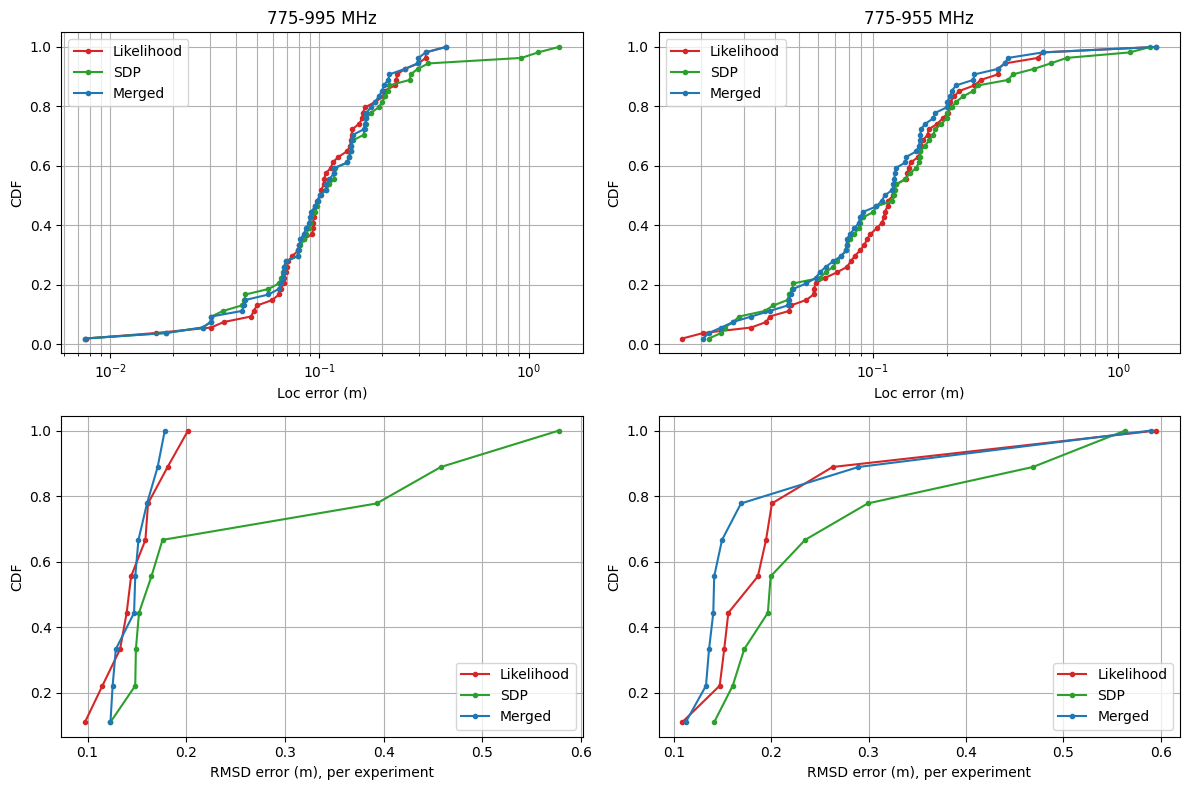

In [9]:
fig, axs = plt.subplots(2, len(BANDS), figsize=(6 * len(BANDS), 8), squeeze=False)
for c, band in enumerate(BANDS):
    for m in METHODS:
        e = np.sort(long.loc[(long["band (MHz)"] == band) & (long.method == m), "error (cm)"] / 100)
        axs[0, c].plot(e, np.arange(1, len(e) + 1) / len(e), ".-", color=COLORS[m], label=m)
        r = np.sort(per_exp.loc[(per_exp["band (MHz)"] == band) & (per_exp.method == m), "RMSD (cm)"] / 100)
        axs[1, c].plot(r, np.arange(1, len(r) + 1) / len(r), ".-", color=COLORS[m], label=m)
    axs[0, c].set_xscale("log"); axs[0, c].set_xlabel("Loc error (m)"); axs[0, c].set_title(f"{band} MHz")
    axs[1, c].set_xlabel("RMSD error (m), per experiment")
    for ax in axs[:, c]:
        ax.set_ylabel("CDF"); ax.grid(which="both"); ax.legend()
plt.tight_layout(); plt.show()

## Estimated vs true positions
Circle = likelihood, triangle = SDP, star = merged (filled star on top of the estimate it took).

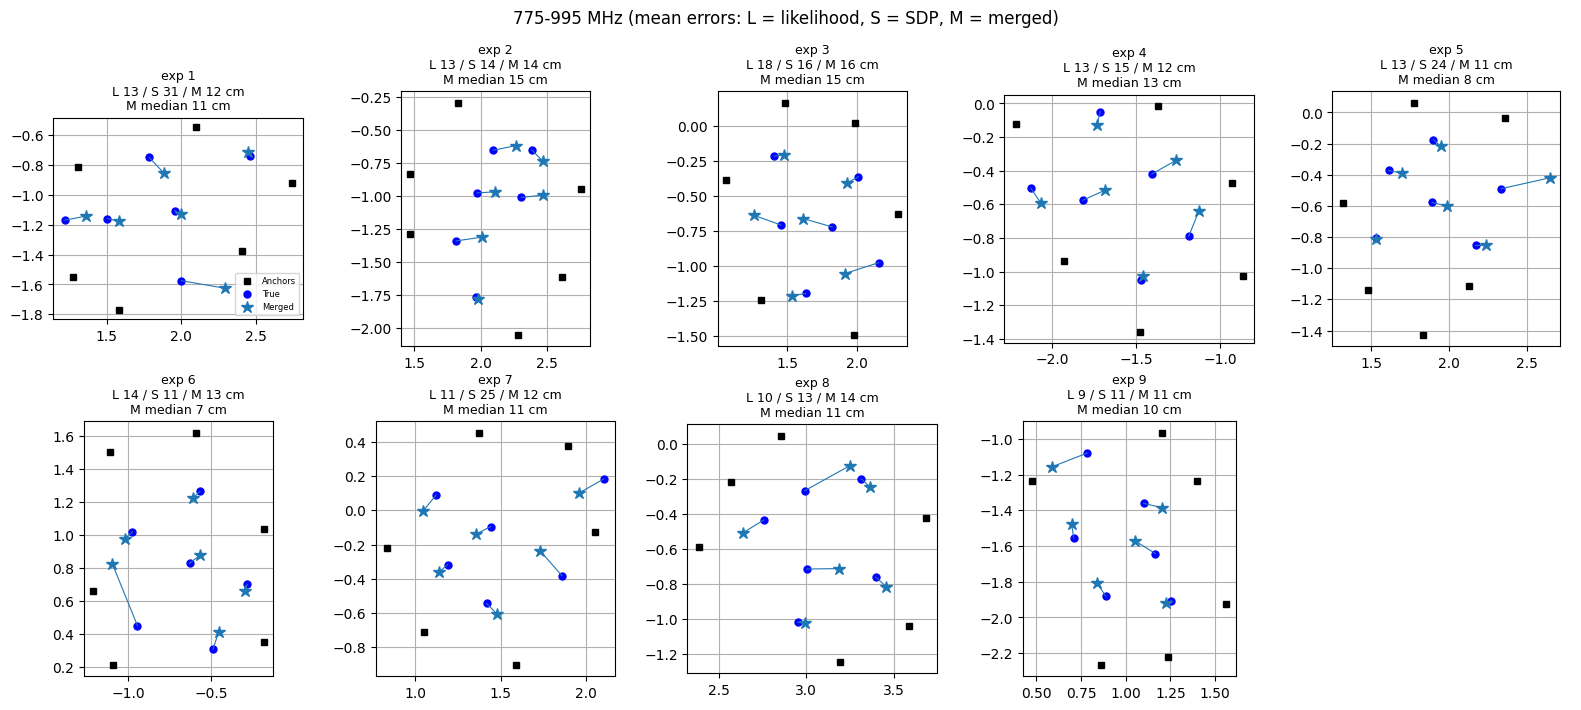

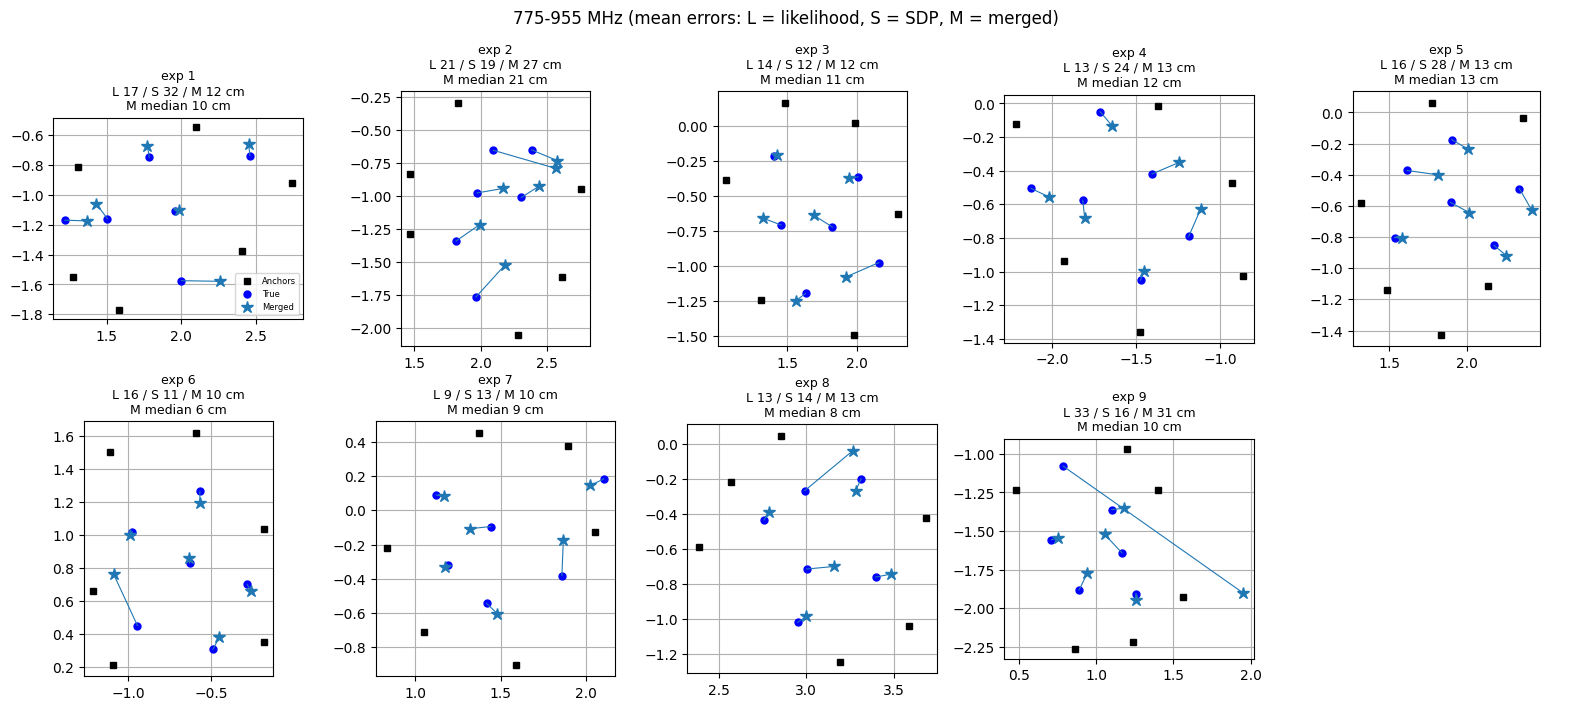

In [10]:
for band in BANDS:
    ncols = int(np.ceil(len(EXPERIMENTS) / 2))
    fig, axs = plt.subplots(2, ncols, figsize=(3.2 * ncols, 7.2), squeeze=False)
    for ax in axs.flat[len(EXPERIMENTS):]:
        ax.axis("off")
    for ax, exp in zip(axs.flat, EXPERIMENTS):
        pts, anchors, tags, ests, use_lkhd = results[exp.name, band]
        ax.plot(*pts[anchors].T, "ks", ms=5, label="Anchors")
        ax.plot(*pts[tags].T, "bo", ms=5, label="True")
        # ax.plot(*ests["Likelihood"].T, "o", mfc="none", color=COLORS["Likelihood"], label="Likelihood")
        # ax.plot(*ests["SDP"].T, "^", mfc="none", color=COLORS["SDP"], label="SDP")
        ax.plot(*ests["Merged"].T, "*", ms=9, color=COLORS["Merged"], label="Merged")
        for t, e in zip(pts[tags], ests["Merged"]):
            ax.plot([t[0], e[0]], [t[1], e[1]], "-", color=COLORS["Merged"], lw=0.8)
        means = {m: loc_errors(pts[tags], e).mean() * 100 for m, e in ests.items()}
        medians = {m: np.median(loc_errors(pts[tags], e)) * 100 for m, e in ests.items()}
        ax.set_title(f"exp {exp.name}\nL {means['Likelihood']:.0f} / S {means['SDP']:.0f} / M {means['Merged']:.0f} cm\nM median {medians['Merged']:.0f} cm", fontsize=9)
        # ax.set_title(f"exp {exp.name}\nL {means['Likelihood']:.0f} / S {means['SDP']:.0f} / M {means['Merged']:.0f} cm", fontsize=9)
        ax.set_aspect("equal"); ax.grid()
    axs[0, 0].legend(fontsize=6)
    fig.suptitle(f"{band} MHz (mean errors: L = likelihood, S = SDP, M = merged)")
    plt.tight_layout(); plt.show()

## Link ranging error before and after localization
For every measured link with at least one non-anchor tag (anchor-anchor links are left out, they are exact after localization), with each link's estimates averaged over runs (the same values the localization uses):
- **Before**: |SVR range (`dist_est_svr`) - true range|.
- **After**: |distance between the localized positions - true range|, with anchors at their true positions and the other tags at their merged estimates.

band (MHz)     775-955  775-995
SVR    mean       13.0     12.2
       median      8.4      7.5
       p90        29.6     28.7
Merged mean        9.5      8.1
       median      6.5      6.3
       p90        20.7     17.3

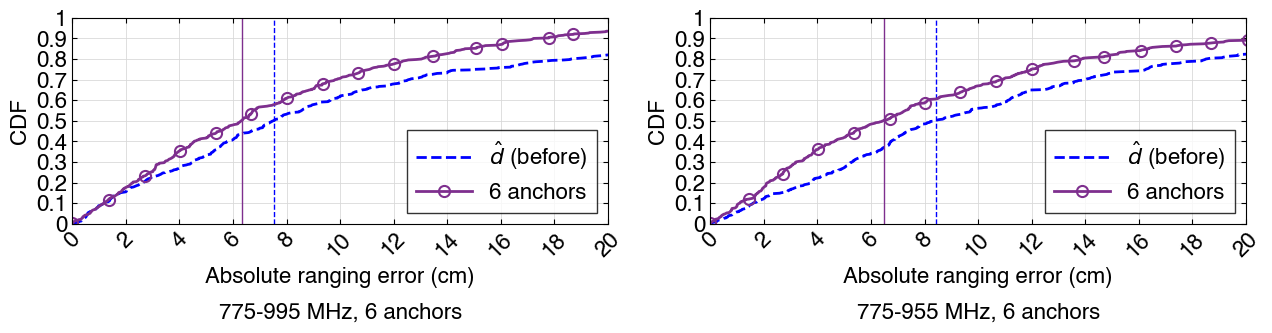

In [16]:
SHOW = {"SVR": "C1", "Merged": COLORS["Merged"]}  # SVR ranges before localization (dashed), merged after


def link_errors(exp, band):
    # One row per link (run-averaged): true range and the abs range error of every input and localization method (cm).
    pts, anchors, tags, ests, _ = results[exp.name, band]
    est = pd.read_csv(exp / "distance_estimates.csv")
    est = est[est["band (MHz)"] == band].assign(
        radius=lambda d: C * d["phase_main"] / (2 * np.pi * MAIN_FREQ * PHASE_MULT) + d["k_est"] * PERIOD)
    links = est.groupby(["tagA_num", "tagB_num"])[["distance", "dist_est_svr", "radius"]].mean().reset_index()
    a, b = links["tagA_num"].to_numpy() - 1, links["tagB_num"].to_numpy() - 1
    links = links[~(np.isin(a, anchors) & np.isin(b, anchors))]
    a, b = links["tagA_num"].to_numpy() - 1, links["tagB_num"].to_numpy() - 1
    out = {"experiment": int(exp.name), "band (MHz)": band, "tagA": a + 1, "tagB": b + 1, "distance": links["distance"].to_numpy(),
           "SVR": np.abs(links["dist_est_svr"] - links["distance"]).to_numpy() * 100,
           "SVR+K": np.abs(links["radius"] - links["distance"]).to_numpy() * 100}
    for m, e in ests.items():
        P = pts.copy()
        P[tags] = e
        out[m] = np.abs(np.linalg.norm(P[a] - P[b], axis=1) - links["distance"].to_numpy()) * 100
    return pd.DataFrame(out)


link_err = pd.concat([link_errors(exp, band) for exp in EXPERIMENTS for band in BANDS], ignore_index=True)
display(link_err.groupby("band (MHz)")[list(SHOW)].agg(["mean", "median", lambda e: e.quantile(0.9)])
        .rename(columns={"<lambda_0>": "p90"}).T.round(1))  # cm

# Styled like the paper's CDF figure (MATLAB look): x 0-20 cm, marked solid line after, blue dashed d-hat before
STYLE = {"SVR": dict(ls="--", lw=2, color=(0, 0, 1), label=r"$\hat{d}$ (before)"),
         "Merged": dict(ls="-", lw=2, color=(0.494, 0.184, 0.556), marker="o", mfc="none", ms=8, mew=1.5,
                        label=f"{N_ANCHORS} anchors")}
with plt.rc_context({"font.family": "sans-serif", "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
                     "font.size": 16, "axes.linewidth": 0.8}):
    fig, axs = plt.subplots(1, len(BANDS), figsize=(6.5 * len(BANDS), 4), squeeze=False)
    for ax, band in zip(axs[0], BANDS):
        sub = link_err[link_err["band (MHz)"] == band]
        for m in SHOW:
            e = np.sort(sub[m])
            p = np.arange(1, len(e) + 1) / len(e)
            # markers at evenly spaced errors (as in the paper figure), not every link
            marks = np.unique(np.searchsorted(e, np.linspace(0, 20, 16)).clip(0, len(e) - 1))
            ax.plot(np.r_[0, e], np.r_[0, p], markevery=list(marks + 1), **STYLE[m])
            ax.axvline(np.median(e), color=STYLE[m]["color"], ls=STYLE[m]["ls"], lw=1)  # median
        ax.set_xlim(0, 20); ax.set_ylim(0, 1)
        ax.set_xticks(np.arange(0, 21, 2)); ax.set_yticks(np.arange(0, 1.01, 0.1), [f"{v:g}" for v in np.arange(0, 1.01, 0.1).round(1)])
        ax.tick_params(axis="x", labelrotation=45, direction="in", top=True)
        ax.tick_params(axis="y", direction="in", right=True)
        ax.grid(color="0.85", lw=0.6); ax.set_axisbelow(True)
        ax.set_xlabel("Absolute ranging error (cm)"); ax.set_ylabel("CDF")
        ax.legend(loc="lower right", fancybox=False, edgecolor="k", handlelength=2.5)
        ax.text(0.5, -0.38, f"{band} MHz, {N_ANCHORS} anchors", transform=ax.transAxes, ha="center", va="top")
    plt.tight_layout(); plt.show()
